### Data cleaning

In [1]:
import pandas as pd
import numpy as np

file_path = "Child_marriage.csv"
df = pd.read_csv(file_path, encoding='utf-8-sig')

print(df.head())
print(df.info())

# rename country column
df = df.rename(columns={"Countries and areas": "country"})

# replace "-" with NaN
df = df.replace("-", np.nan)

# convert numeric
num_cols = [
    "female_married_by_15",
    "female_married_by_18",
    "male_married_by_18"
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# remove empty country rows
df = df[df["country"].notna()].copy()

# create derived indicators
df["marriage_gap_18"] = (
    df["female_married_by_18"] -
    df["male_married_by_18"]
)

df["early_marriage_ratio"] = (
    df["female_married_by_15"] /
    df["female_married_by_18"]
)

# keep clean dataset
child_marriage_clean = df[[
    "country",
    "female_married_by_15",
    "female_married_by_18",
    "male_married_by_18",
    "marriage_gap_18",
    "early_marriage_ratio"
]]

print(child_marriage_clean.head())
print(child_marriage_clean.describe())

# save
child_marriage_clean.to_csv("Child_marriage_clean.csv", index=False)

  Countries and areas female_married_by_15 female_married_by_18  \
0         Afghanistan                   10                   29   
1             Albania                    1                   12   
2             Algeria                    0                    4   
3             Andorra                    -                    -   
4              Angola                    8                   30   

  male_married_by_18  
0                  7  
1                  1  
2                  -  
3                  -  
4                  6  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203 entries, 0 to 202
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Countries and areas   203 non-null    object
 1   female_married_by_15  203 non-null    object
 2   female_married_by_18  203 non-null    object
 3   male_married_by_18    203 non-null    object
dtypes: object(4)
memory usage: 6.5+ KB
None
       cou

### Data Sanity Check

In [2]:
print("Countries:", child_marriage_clean["country"].nunique())
print("Missing values:")
print(child_marriage_clean.isna().sum())

Countries: 203
Missing values:
country                   0
female_married_by_15     63
female_married_by_18     60
male_married_by_18      104
marriage_gap_18         104
early_marriage_ratio     68
dtype: int64


### Visualisation

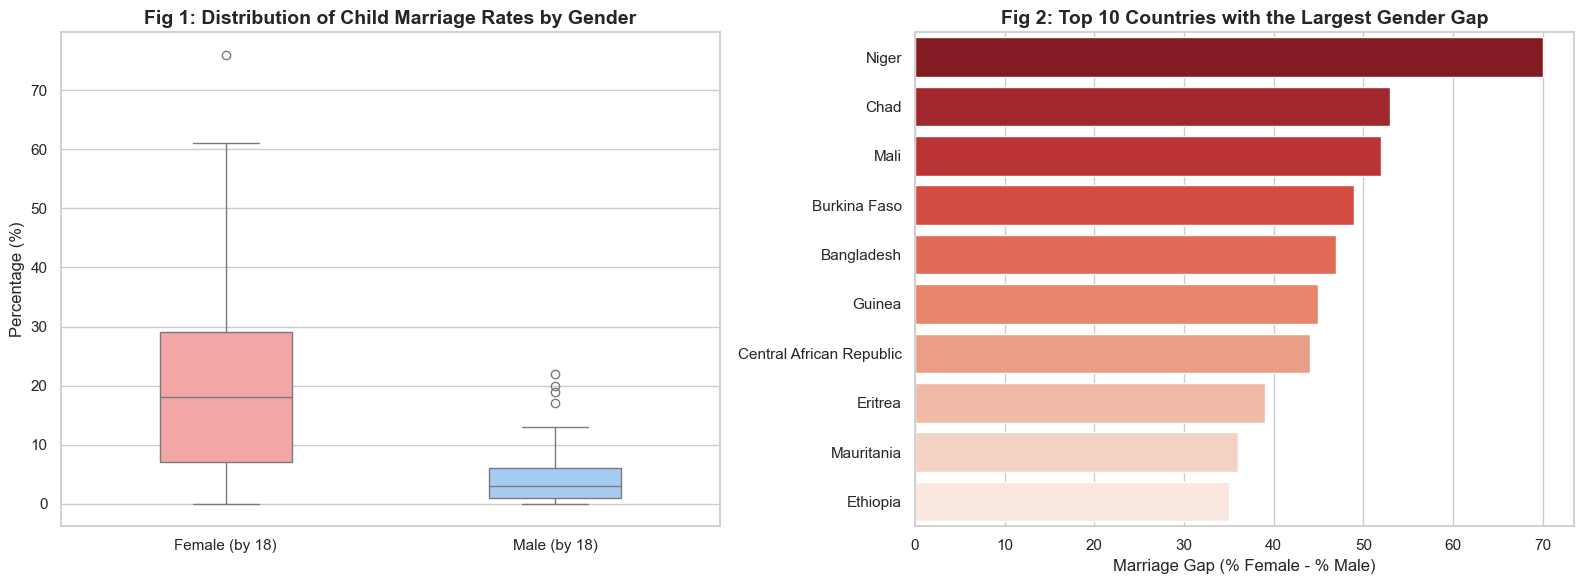

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set academic-style chart theme
sns.set_theme(style="whitegrid", palette="pastel")

# Create a 1x2 figure layout
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ==========================================
# Fig 1: Distribution of child marriage rates by gender (Boxplot)
# ==========================================
df_melted = child_marriage_clean.melt(
    value_vars=['female_married_by_18', 'male_married_by_18'], 
    var_name='Gender', value_name='Marriage_Rate'
)
df_melted['Gender'] = df_melted['Gender'].replace({
    'female_married_by_18': 'Female (by 18)', 
    'male_married_by_18': 'Male (by 18)'
})

sns.boxplot(
    data=df_melted, x='Gender', y='Marriage_Rate', 
    hue='Gender', legend=False, 
    width=0.4, ax=axes[0], palette=["#ff9999", "#99ccff"]
)
axes[0].set_title('Fig 1: Distribution of Child Marriage Rates by Gender', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_xlabel('')

# ==========================================
# Fig 2: Top 10 countries with the largest gender gap (Bar Chart)
# ==========================================
top_10_gap = child_marriage_clean.nlargest(10, 'marriage_gap_18')

sns.barplot(
    data=top_10_gap, 
    x='marriage_gap_18', 
    y='country', 
    hue='country', legend=False,
    ax=axes[1], 
    palette='Reds_r' 
)
axes[1].set_title('Fig 2: Top 10 Countries with the Largest Gender Gap', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Marriage Gap (% Female - % Male)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()